In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv("credit_risk_dataset.csv")

In [ ]:
print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [ ]:
df["loan_status"].value_counts()

,count
loan_status,
0,25473
1,7108


In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop("loan_status",axis=1)
y = df["loan_status"]
print("features:", x.shape)
print("target:", y.shape)

features: (32581, 11)
target: (32581,)


In [ ]:
x = pd.get_dummies(x,drop_first=True)
print(x.shape)
x.head()

(32581, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)
print("Training:", x_train.shape)
print("Testing:", x_test.shape)

Training: (26064, 22)
Testing: (6517, 22)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [ ]:
predictions = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.9315636028847629


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.96      0.73      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



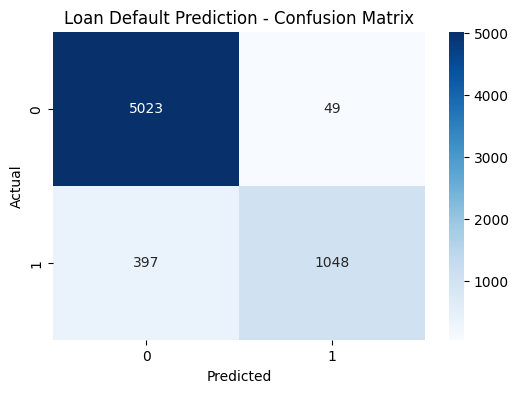

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Default Prediction - Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
5,loan_percent_income,0.217599
1,person_income,0.149631
4,loan_int_rate,0.127270
3,loan_amnt,0.080291
9,person_home_ownership_RENT,0.077081
2,person_emp_length,0.061675
17,loan_grade_D,0.051542
0,person_age,0.049476
6,cb_person_cred_hist_length,0.037389
16,loan_grade_C,0.019204


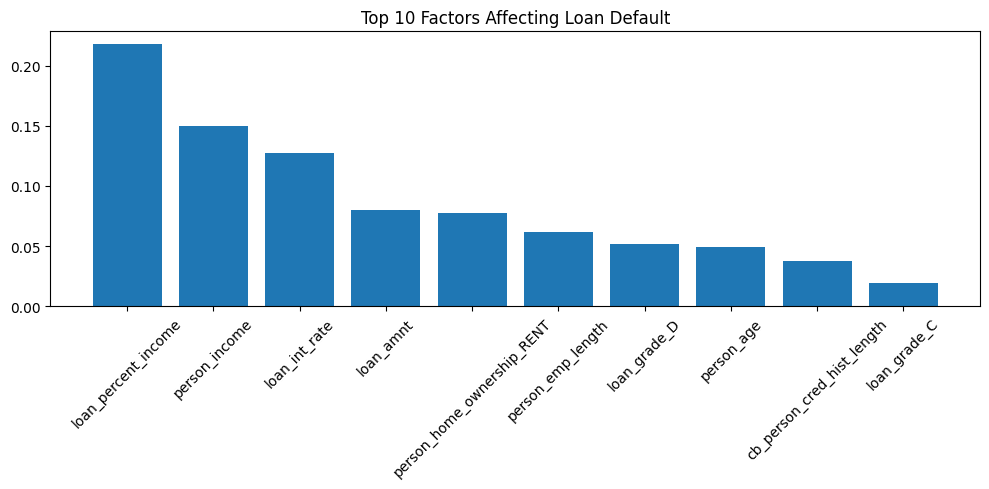

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Feature'], top10['Importance'])
plt.xticks(rotation=45)
plt.title("Top 10 Factors Affecting Loan Default")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

new_customer = pd.DataFrame([{
    'person_age': 30,
    'person_income': 60000,
    'person_emp_length': 5,
    'loan_amnt': 10000,
    'loan_int_rate': 10,
    'loan_percent_income': 0.16,
    'cb_person_cred_hist_length': 5,

    'person_home_ownership_OTHER': 0,
    'person_home_ownership_OWN': 0,
    'person_home_ownership_RENT': 1,

    'loan_grade_B': 1,
    'loan_grade_C': 0,
    'loan_grade_D': 0,
    'loan_grade_E': 0,
    'loan_grade_F': 0,
    'loan_grade_G': 0,

    # add the remaining dummy columns shown in x.columns
}])

In [ ]:
new_customer['person_age'] = 30
new_customer['person_income'] = 60000
new_customer['person_emp_length'] = 5
new_customer['loan_amnt'] = 10000
new_customer['loan_int_rate'] = 10
new_customer['loan_percent_income'] = 0.16
new_customer['cb_person_cred_hist_length'] = 5

# Home ownership
new_customer['person_home_ownership_RENT'] = 1

# Loan purpose
new_customer['loan_intent_PERSONAL'] = 1

# Loan grade
new_customer['loan_grade_B'] = 1

# Previous default?
new_customer['cb_person_default_on_file_Y'] = 0

In [ ]:
print(x.columns.tolist())

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


In [ ]:
new_customer = pd.DataFrame(0, index=[0], columns=x.columns)

In [ ]:
print(new_customer.columns.tolist())

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


In [ ]:
new_customer['person_age'] = 30
new_customer['person_income'] = 60000
new_customer['person_emp_length'] = 5
new_customer['loan_amnt'] = 10000
new_customer['loan_int_rate'] = 10
new_customer['loan_percent_income'] = 0.16
new_customer['cb_person_cred_hist_length'] = 5

new_customer['person_home_ownership_RENT'] = 1
new_customer['loan_intent_PERSONAL'] = 1
new_customer['loan_grade_B'] = 1
new_customer['cb_person_default_on_file_Y'] = 0

In [ ]:
print(new_customer.shape)
print(x.shape)

(1, 22)
(32581, 22)


In [ ]:
prediction = model.predict(new_customer)

if prediction[0] == 0:
    print("Loan likely SAFE")
else:
    print("High risk of DEFAULT")

Loan likely SAFE
